In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_property = pd.read_csv('data/eda.csv')
df_property.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [3]:
df_property.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [4]:
df_property.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [5]:
df_property.dtypes

id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
date                 str
price            float64
dtype: object

In [6]:
type(df_property['date'][0])

str

In [7]:
# change "date" dtype to datetime with format %Y/%m/%d
df_property['date'] = pd.to_datetime(df_property['date'], format = '%Y-%m-%d')

In [8]:
type(df_property['date'][0])

pandas.Timestamp

In [9]:
# Returns the count of missing values per column
df_property.isnull().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

<Axes: >

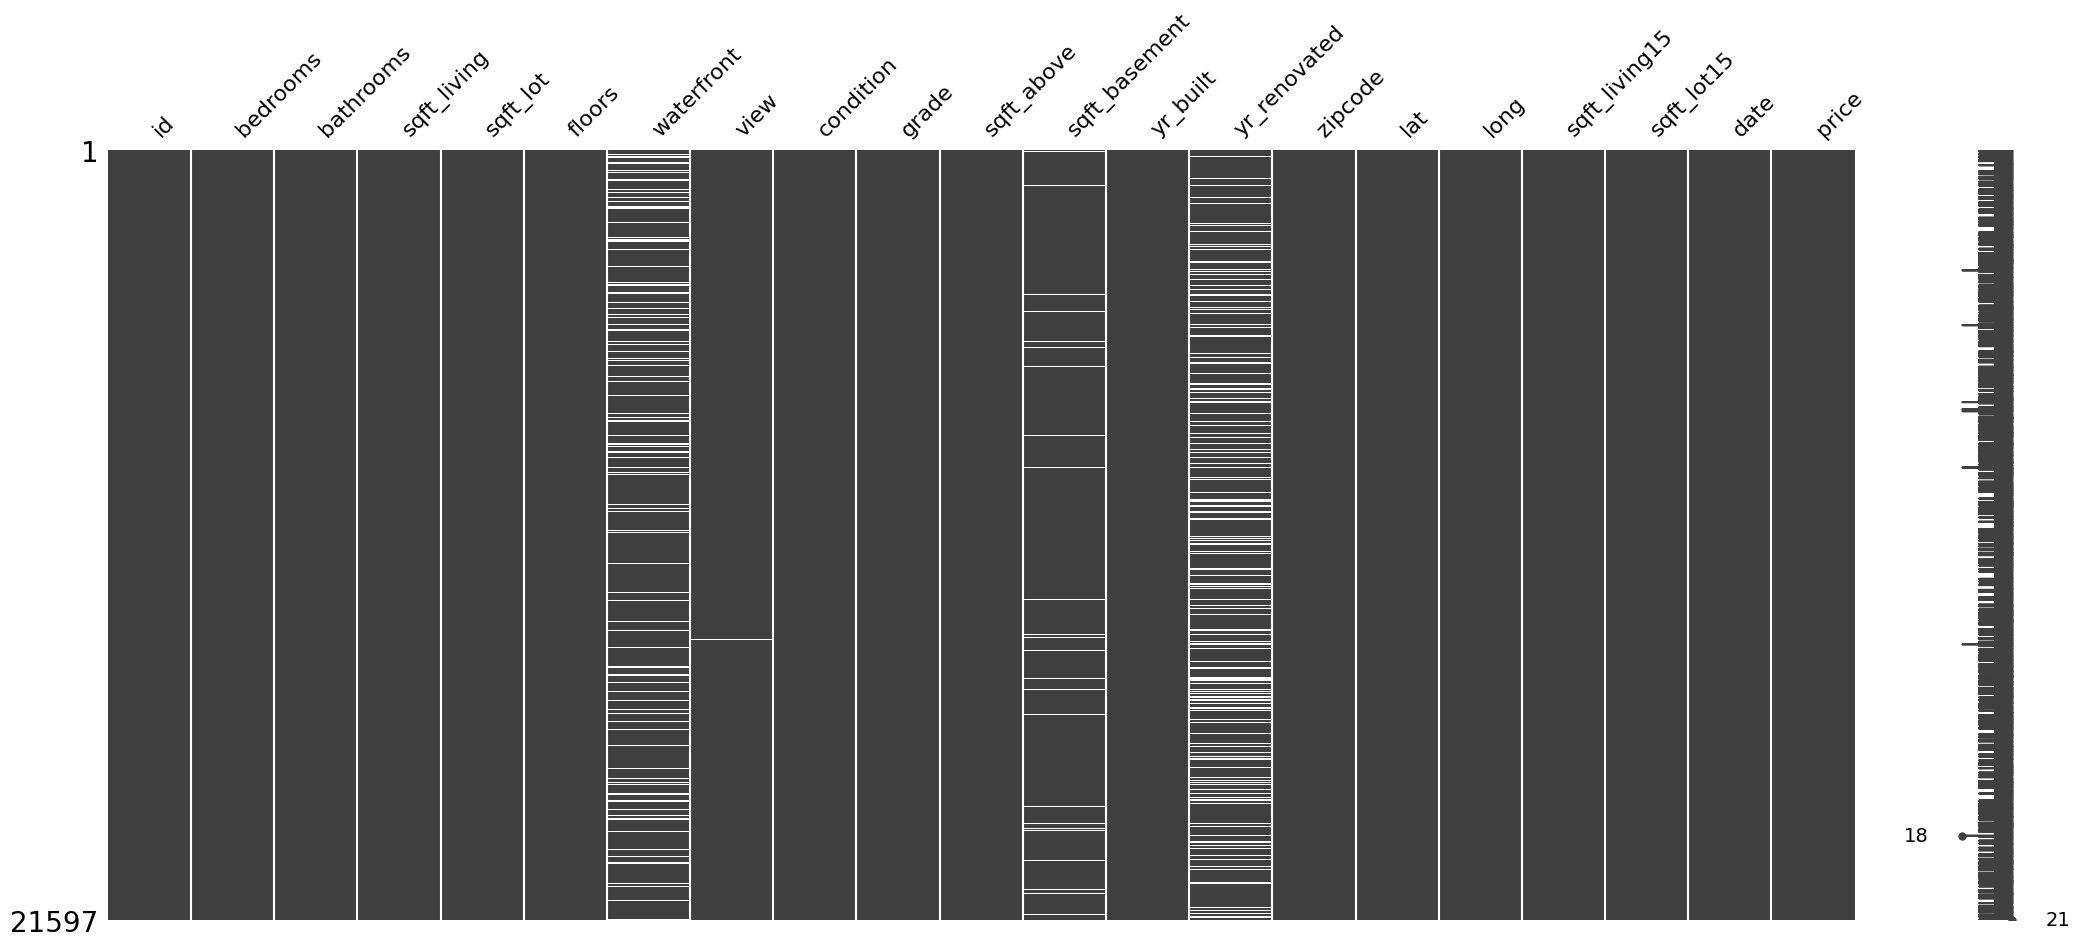

In [10]:
import missingno as msno

# Visualizes the location of missing values
msno.matrix(df_property)

<Axes: >

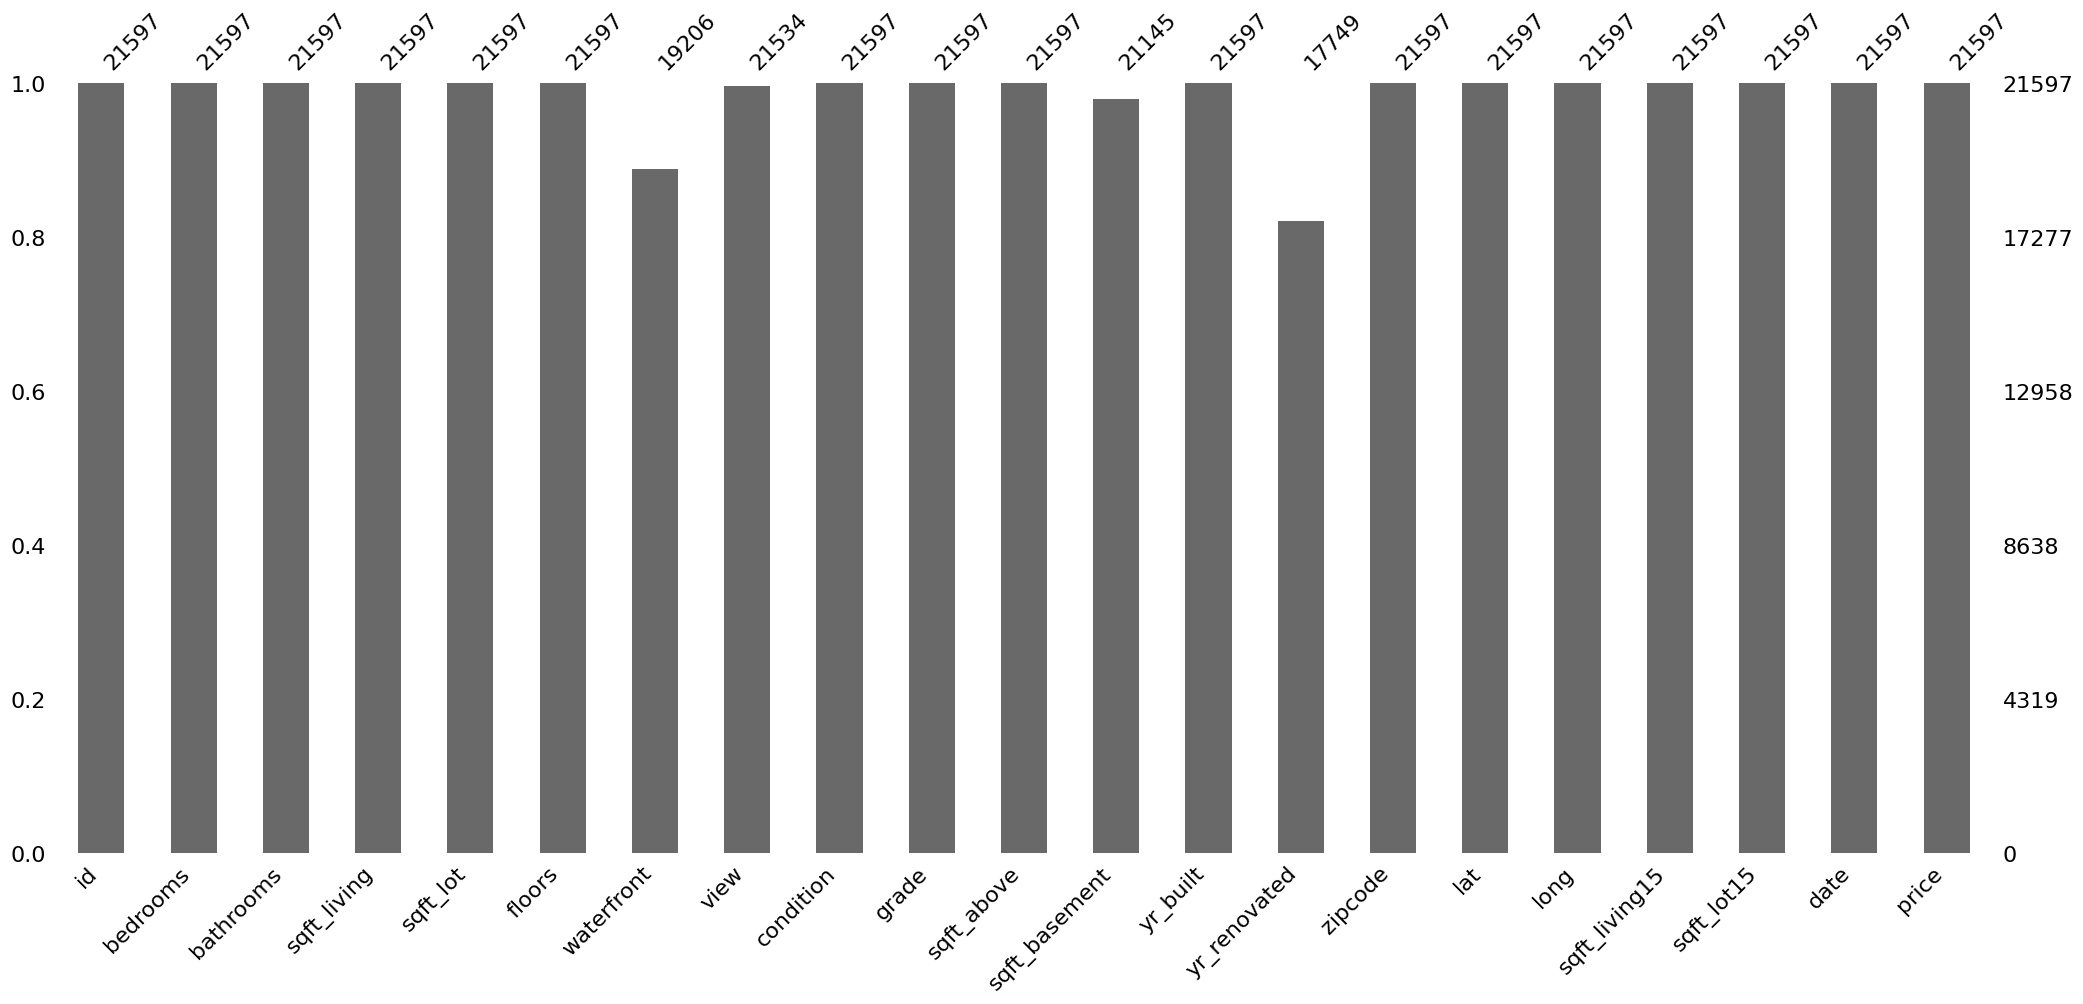

In [11]:
msno.bar(df_property)

In [12]:
df_property['waterfront'] = df_property['waterfront'].fillna(0, inplace=True)
df_property['view'] = df_property['view'].fillna(df_property['view'].mode()[0])
df_property['sqft_basement'] = df_property['sqft_basement'].fillna(0)
df_property['yr_renovated'] = df_property['yr_renovated'].fillna(0)

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_13947/2905862259.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_property['waterfront'] = df_property['waterfront'].fillna(0, inplace=True)


In [13]:
df_property.isnull().sum()

id               0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
date             0
price            0
dtype: int64

In [28]:
# Look at the 'max' value in the output
df_property['bedrooms'].describe()

count    21597.000000
mean         3.373200
std          0.926299
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         33.000000
Name: bedrooms, dtype: float64

In [29]:
# Show the details for any house with more than 10 bedrooms
df_property[df_property['bedrooms'] > 10][['id', 'bedrooms', 'sqft_living', 'price']]

,id,bedrooms,sqft_living,price
8748,1773100755,11.0,3000.0,520000.0
15856,2402100895,33.0,1620.0,640000.0


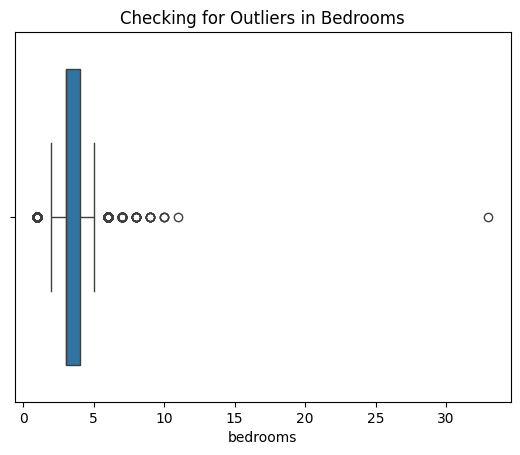

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_property['bedrooms'])
plt.title("Checking for Outliers in Bedrooms")
plt.show()

In data cleaning process, I compared other 3 bedroom properties sqft_living area and replaced 33 with 3.

In [32]:
# Identify and fix the outlier in the 'bedrooms' column
# We change 33 to 3 because a 1,620 sqft house cannot realistically have 33 bedrooms
df_property.loc[df_property['bedrooms'] == 33, 'bedrooms'] = 3

#Verification: Check the new maximum value
print("New Maximum Bedrooms:", df_property['bedrooms'].max())

New Maximum Bedrooms: 11.0


In [14]:
# To see the top 10 highest priced houses
top_houses = df_property.nlargest(10, 'price')

print(top_houses[['price', 'zipcode', 'lat', 'long']])

          price  zipcode      lat     long
7245  7700000.0    98102  47.6298 -122.323
3910  7060000.0    98004  47.6500 -122.214
9245  6890000.0    98039  47.6305 -122.240
4407  5570000.0    98039  47.6289 -122.233
1446  5350000.0    98004  47.6232 -122.220
1313  5300000.0    98040  47.5631 -122.210
1162  5110000.0    98033  47.6767 -122.211
8085  4670000.0    98040  47.5570 -122.210
2624  4500000.0    98155  47.7493 -122.280
8629  4490000.0    98004  47.6208 -122.219


The mean of lat and long give exact radius as a central area (here there is no outlier in both the data as mean and median values are almost same).

In [15]:
# Calculate the center point for latitude and longitude
center_lat = df_property['lat'].mean()
center_long = df_property['long'].mean()

print(f"The center of the dataset is at: {center_lat}, {center_long}")

The center of the dataset is at: 47.56009299439737, -122.21398254294577


In [16]:
# Finding the house closest to the average center
center_house = df_property.iloc[((df_property['lat'] - center_lat)**2 + 
                                 (df_property['long'] - center_long)**2).idxmin()]

print(f"The center is near Zip Code: {center_house['zipcode']}")

The center is near Zip Code: 98040


In [17]:
# Identify the Geographic Center (Median Lat/Long)
center_lat = df_property['lat'].median()
center_lat

np.float64(47.5718)

In [18]:
# Identify the Geographic Center (Median Long)
center_long = df_property['long'].median()
center_long

np.float64(-122.231)

The time features are helpful to derive golden window for selling properties.

In [19]:
#Extract time features
df_property['month'] = df_property['date'].dt.month
df_property['month_name'] = df_property['date'].dt.month_name()

Distance from center gives the exact area where prices are highest.

In [21]:
#Calculate Distance from Center
df_property['dist_from_center'] = np.sqrt((df_property['lat'] - center_lat)**2 + (df_property['long'] - center_long)**2)
df_property['dist_from_center']

0        0.065942
1        0.173218
2        0.166112
3        0.169838
4        0.191366
           ...   
21592    0.171701
21593    0.144548
21594    0.071657
21595    0.166239
21596    0.071563
Name: dist_from_center, Length: 21597, dtype: float64

In [22]:
#Central and Expensive
price_75th = df_property['price'].quantile(0.75)
price_75th

np.float64(645000.0)

In [23]:
df_property['is_central'] = df_property['dist_from_center'] < 0.1
df_property['is_central'].value_counts()

is_central
False    17930
True      3667
Name: count, dtype: int64

In [24]:
df_property['is_expensive'] = df_property['price'] > price_75th
df_property['is_expensive'].value_counts()

is_expensive
False    16226
True      5371
Name: count, dtype: int64

In [26]:
df_property['is_renovated'] = df_property['yr_renovated'] > 0
df_property['is_renovated'].value_counts()

is_renovated
False    20853
True       744
Name: count, dtype: int64

In [27]:
# 1. Create a new dataframe containing only houses with grade > 9
high_grade_houses = df_property[df_property['grade'] > 9]
high_grade_houses.value_counts()

id          bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  grade  sqft_above  sqft_basement  yr_built  yr_renovated  zipcode  lat      long      sqft_living15  sqft_lot15  date        price      month  month_name  dist_from_center  is_central  is_expensive  is_renovated
7237550310  4.0       4.50       5420.0       101930.0  1.0     0.0         0.0   3          11     3890.0      1530.0         2001      0.0           98053    47.6561  -122.005  4760.0         101930.0    2014-05-12  1230000.0  5      May         0.241210          False       True          False           1
3394100030  4.0       2.50       2720.0       11049.0   2.0     0.0         0.0   3          10     2720.0      0.0            1989      0.0           98004    47.5815  -122.192  2750.0         11049.0     2014-09-09  975000.0   9      September   0.040188          True        True          False           1
1525059190  5.0       3.25       4770.0       50094.0   1.0     0.0        

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_13947/2950064251.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


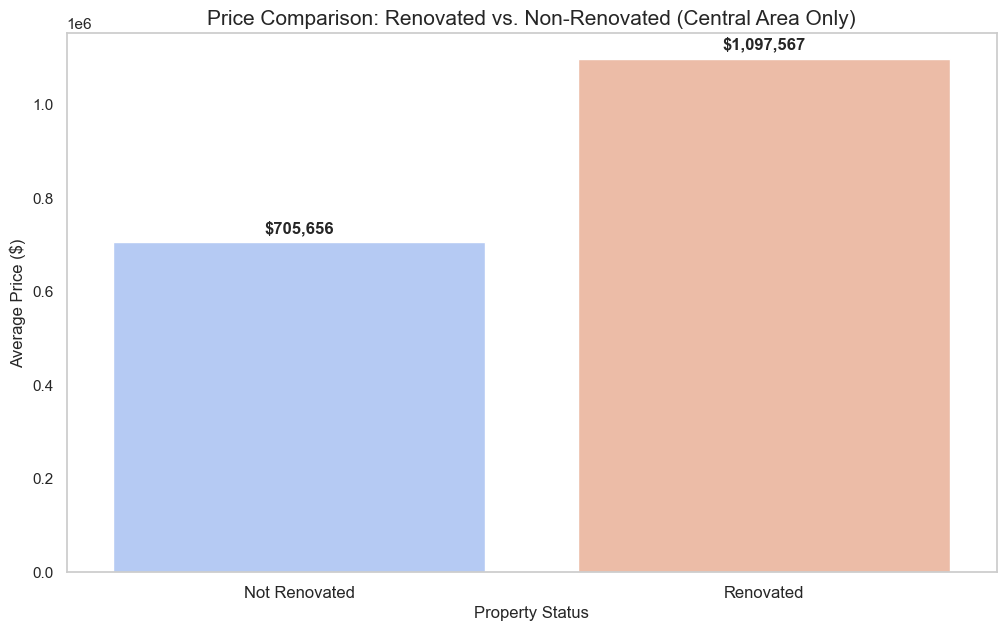

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter the data for the "Central Area" 
# We define 'Central' as houses within 0.1 degrees of the geographic center
central_houses = df_property[df_property['dist_from_center'] < 0.1]

# 2. Create the Comparison Graph
plt.figure(figsize=(12, 7))

# We use a Bar Plot to compare the Average (Mean) prices clearly
sns.barplot(
    data=central_houses, 
    x='is_renovated', 
    y='price', 
    palette='coolwarm',
    errorbar=None  # Set to None for a cleaner view of the averages
)

# 3. Add labels that make sense for Timothy
plt.title("Price Comparison: Renovated vs. Non-Renovated (Central Area Only)", fontsize=15)
plt.xticks([0, 1], ['Not Renovated', 'Renovated'], fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.xlabel("Property Status", fontsize=12)

# 4. Add the actual price numbers on top of the bars
for i, p in enumerate(central_houses.groupby('is_renovated')['price'].mean()):
    plt.text(i, p + 20000, f'${p:,.0f}', ha='center', fontweight='bold')
plt.grid(False)
plt.show()

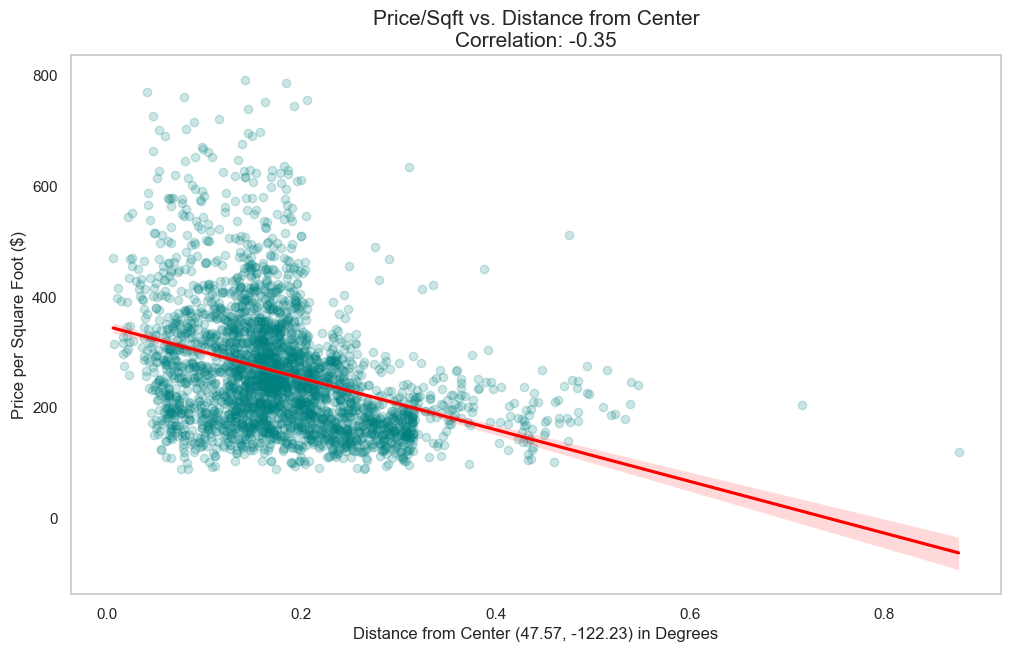

In [ ]:
#Timothy can get good price as the central poroperties have highest price per square foot.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Feature Engineering: Create the dependent variable
df_property['price_per_sqft'] = df_property['price'] / df_property['sqft_living']

# 2. Define Timothy's target coordinates
target_lat = 47.57
target_long = -122.23

# 3. Calculate distance from every house to this target point
# We use Euclidean distance as a proxy for physical distance in degrees
df_property['dist_to_target'] = np.sqrt(
    (df_property['lat'] - target_lat)**2 + 
    (df_property['long'] - target_long)**2
)

# 4. Statistical Test (Pearson Correlation)
# This checks if distance and price-per-sqft move together
corr, _ = pearsonr(df_property['dist_to_target'], df_property['price_per_sqft'])

# 5. Visualization: Regression Plot
plt.figure(figsize=(12, 7))
sns.regplot(
    data=df_property.sample(3000), # Sample for faster rendering
    x='dist_to_target', 
    y='price_per_sqft', 
    scatter_kws={'alpha':0.2, 'color':'teal'}, 
    line_kws={'color':'red'}
)

plt.title(f"Price/Sqft vs. Distance from Center\nCorrelation: {corr:.2f}", fontsize=15)
plt.xlabel("Distance from Center (47.57, -122.23) in Degrees")
plt.ylabel("Price per Square Foot ($)")
plt.grid(False)
plt.show()

--- Seasonal Analysis ---
Spring Average Price: $552,782.76
Winter Average Price: $519,613.65
The 'Spring Premium' is: $33,169.12 (6.38%)


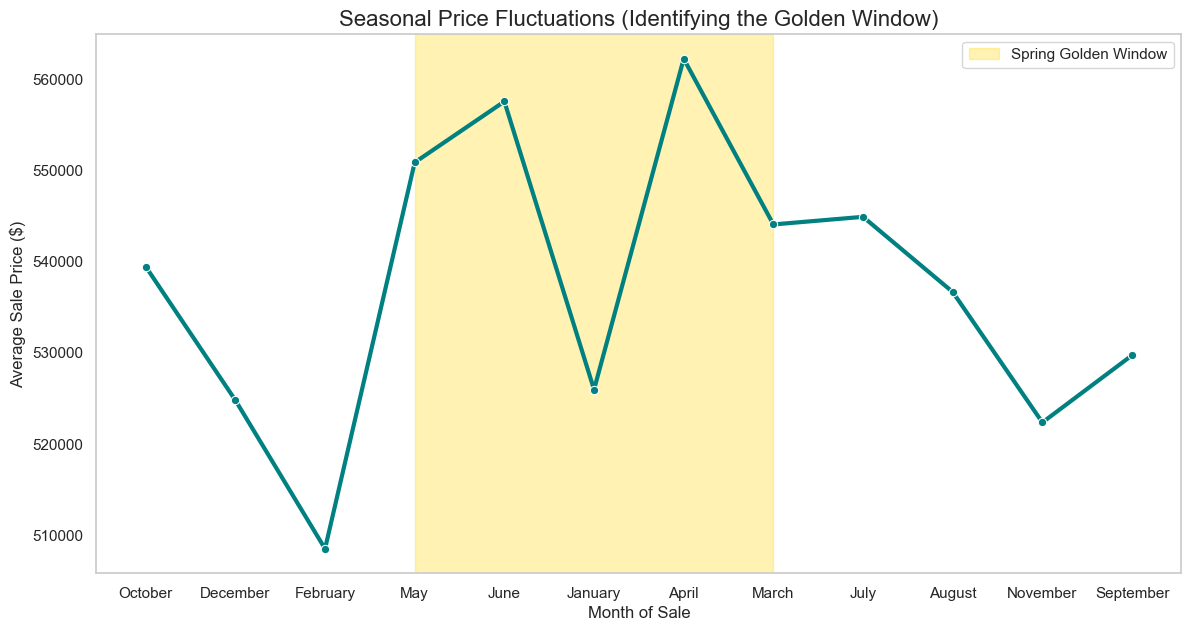

In [ ]:
#Timothy should finish his renovation by February and list his central properties in Spring to get more prices.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure 'date' is in datetime format and extract months
df_property['date'] = pd.to_datetime(df_property['date'])
df_property['month'] = df_property['date'].dt.month
df_property['month_name'] = df_property['date'].dt.month_name()

# 2. Define our "Seasons" based on Timothy's Hypothesis
# Spring/Golden Window: March, April, May
# Winter: December, January, February
def define_season(month):
    if month in [3, 4, 5]:
        return 'Spring (Golden Window)'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Other'

df_property['season'] = df_property['month'].apply(define_season)

# 3. Calculate the Price Difference
season_stats = df_property[df_property['season'] != 'Other'].groupby('season')['price'].mean()
spring_avg = season_stats['Spring (Golden Window)']
winter_avg = season_stats['Winter']
price_diff = spring_avg - winter_avg
percent_increase = (price_diff / winter_avg) * 100

print(f"--- Seasonal Analysis ---")
print(f"Spring Average Price: ${spring_avg:,.2f}") # 553k dollars
print(f"Winter Average Price: ${winter_avg:,.2f}") # 520k dollars
print(f"The 'Spring Premium' is: ${price_diff:,.2f} ({percent_increase:.2f}%)") # 33k dollars price premium

# 4. Visualization: Monthly Trend and Seasonal Highlight
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create a Line Plot of average price by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

sns.lineplot(data=df_property, x='month_name', y='price', estimator='mean', 
             errorbar=None, marker='o', linewidth=3, color='teal', sort=False)

# Highlight the "Golden Window"
plt.axvspan('March', 'May', color='gold', alpha=0.3, label='Spring Golden Window')

plt.title("Seasonal Price Fluctuations (Identifying the Golden Window)", fontsize=16)
plt.ylabel("Average Sale Price ($)", fontsize=12)
plt.xlabel("Month of Sale", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()

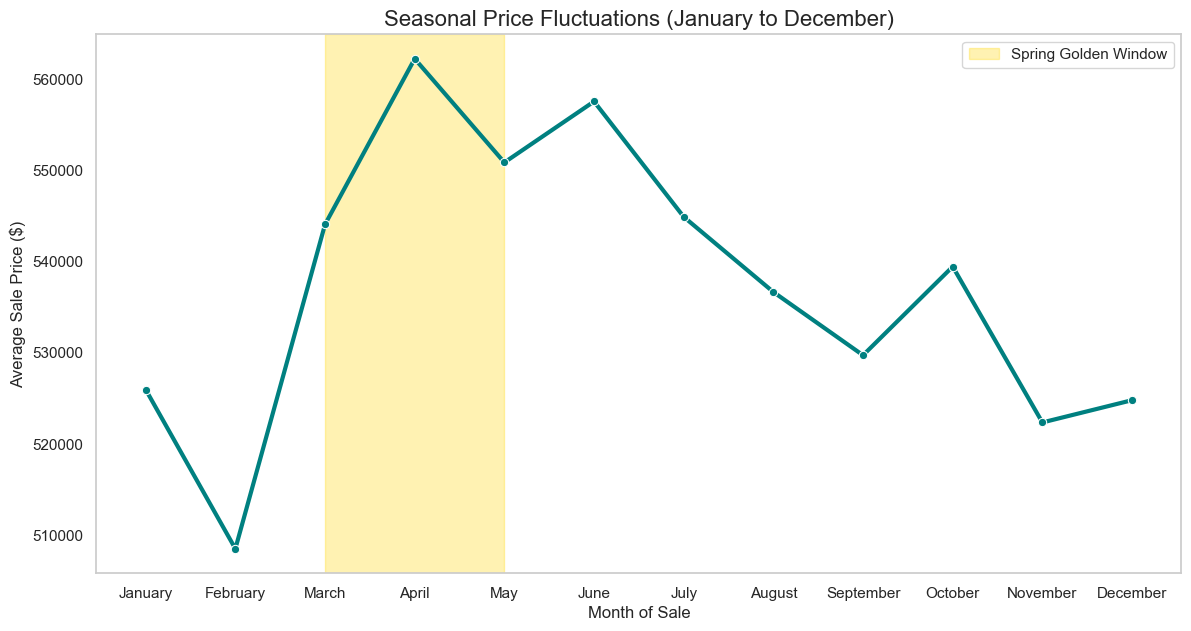

In [45]:
# 1. Group the data by month to get one average price per month
# This ensures we don't have multiple overlapping data points for the same month across different years
monthly_avg = df_property.groupby(['month', 'month_name'])['price'].mean().reset_index()

# 2. Sort explicitly by the numerical month (1-12)
monthly_avg = monthly_avg.sort_values('month')

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Use monthly_avg instead of df_property to ensure only one point per month is plotted
sns.lineplot(data=monthly_avg, x='month_name', y='price', 
             marker='o', linewidth=3, color='teal', sort=False)

# Highlight the "Golden Window" (March to May)
plt.axvspan('March', 'May', color='gold', alpha=0.3, label='Spring Golden Window')

plt.title("Seasonal Price Fluctuations (January to December)", fontsize=16)
plt.ylabel("Average Sale Price ($)", fontsize=12)
plt.xlabel("Month of Sale", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()